In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
df = pd.read_csv("World Energy Consumption.csv")
df

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22007,Zimbabwe,2018,ZWE,15052191.0,2.271535e+10,NaN,NaN,NaN,NaN,25.910,...,0.218,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22008,Zimbabwe,2019,ZWE,15354606.0,NaN,NaN,NaN,NaN,NaN,24.748,...,0.364,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22009,Zimbabwe,2020,ZWE,15669663.0,NaN,NaN,NaN,NaN,NaN,22.336,...,0.395,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22010,Zimbabwe,2021,ZWE,15993525.0,NaN,NaN,NaN,NaN,NaN,23.760,...,0.498,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN


In [3]:
# First five rows
df.head()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN


In [4]:
# Last five rows
df.tail()

,country,year,iso_code,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
22007,Zimbabwe,2018,ZWE,15052191.0,2.271535e+10,NaN,NaN,NaN,NaN,25.910,...,0.218,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22008,Zimbabwe,2019,ZWE,15354606.0,NaN,NaN,NaN,NaN,NaN,24.748,...,0.364,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22009,Zimbabwe,2020,ZWE,15669663.0,NaN,NaN,NaN,NaN,NaN,22.336,...,0.395,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22010,Zimbabwe,2021,ZWE,15993525.0,NaN,NaN,NaN,NaN,NaN,23.760,...,0.498,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0.0,NaN
22011,Zimbabwe,2022,ZWE,16320539.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Total Count rows and columns 
df.shape

(22012, 129)

In [6]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22012 entries, 0 to 22011
Columns: 129 entries, country to wind_share_energy
dtypes: float64(126), int64(1), object(2)
memory usage: 21.5+ MB


In [7]:
# Statistical summary of dataset
df.describe()

,year,population,gdp,biofuel_cons_change_pct,biofuel_cons_change_twh,biofuel_cons_per_capita,biofuel_consumption,biofuel_elec_per_capita,biofuel_electricity,biofuel_share_elec,...,solar_share_elec,solar_share_energy,wind_cons_change_pct,wind_cons_change_twh,wind_consumption,wind_elec_per_capita,wind_electricity,wind_energy_per_capita,wind_share_elec,wind_share_energy
count,22012.000000,1.812300e+04,1.111300e+04,1747.000000,2687.000000,2302.000000,2767.000000,5275.000000,5527.000000,5492.000000,...,6849.000000,4035.000000,2413.000000,4639.000000,4744.000000,7065.000000,7996.000000,4065.000000,6886.000000,4101.000000
mean,1974.213247,1.053096e+08,3.585114e+11,46.091694,2.719074,133.558459,38.068209,64.716800,10.966685,1.954035,...,0.622750,0.210395,267.541206,7.314174,53.422938,62.811828,17.561153,232.108949,1.404910,0.651413
std,35.058653,4.640460e+08,2.411179e+12,274.616745,10.057018,264.707851,111.623148,201.043915,47.953561,5.274155,...,2.066186,0.643304,5940.944120,37.327922,273.255306,252.734217,101.693172,733.841324,4.489043,1.893820
min,1900.000000,1.833000e+03,1.642060e+08,-100.000000,-50.843000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-100.000000,-51.208000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1946.000000,1.712404e+06,1.365898e+10,-0.616500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.029000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1984.000000,6.991543e+06,4.167411e+10,8.179000,0.000000,15.482000,0.673000,0.146000,0.010000,0.062000,...,0.000000,0.000000,20.000000,0.000000,0.005000,0.000000,0.000000,0.051000,0.000000,0.003000
75%,2003.000000,2.557688e+07,1.744295e+11,26.508500,0.861500,165.266750,13.629500,34.289000,0.690000,1.577500,...,0.095000,0.018500,47.971000,0.315000,2.357750,2.101000,0.140000,45.523000,0.372000,0.268000
max,2022.000000,7.975105e+09,1.136302e+14,5659.328000,141.131000,2588.512000,1199.207000,2514.102000,677.570000,71.429000,...,40.000000,7.586000,242384.844000,665.413000,5487.600000,3219.852000,2139.230000,8422.012000,56.840000,26.157000


In [8]:
# Column names 
df.columns 

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='object', length=129)

In [9]:
# Standardize column names
df.columns = (
    df.columns.
        str.strip().
        str.lower().
        str.replace(' ', '_')
)
print(df.columns.tolist())

['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct', 'biofuel_cons_change_twh', 'biofuel_cons_per_capita', 'biofuel_consumption', 'biofuel_elec_per_capita', 'biofuel_electricity', 'biofuel_share_elec', 'biofuel_share_energy', 'carbon_intensity_elec', 'coal_cons_change_pct', 'coal_cons_change_twh', 'coal_cons_per_capita', 'coal_consumption', 'coal_elec_per_capita', 'coal_electricity', 'coal_prod_change_pct', 'coal_prod_change_twh', 'coal_prod_per_capita', 'coal_production', 'coal_share_elec', 'coal_share_energy', 'electricity_demand', 'electricity_generation', 'electricity_share_energy', 'energy_cons_change_pct', 'energy_cons_change_twh', 'energy_per_capita', 'energy_per_gdp', 'fossil_cons_change_pct', 'fossil_cons_change_twh', 'fossil_elec_per_capita', 'fossil_electricity', 'fossil_energy_per_capita', 'fossil_fuel_consumption', 'fossil_share_elec', 'fossil_share_energy', 'gas_cons_change_pct', 'gas_cons_change_twh', 'gas_consumption', 'gas_elec_per_capita', '

In [10]:
# Chek null value count
print(df.isnull().sum())

country                       0
year                          0
iso_code                   5500
population                 3889
gdp                       10899
                          ...  
wind_elec_per_capita      14947
wind_electricity          14016
wind_energy_per_capita    17947
wind_share_elec           15126
wind_share_energy         17911
Length: 129, dtype: int64


In [13]:
# Important columns 
cols_to_keep = ['country', 'year', 'primary_energy_consumption', 'gdp', 'population']
us_data = df[df['country'] == 'United States'][cols_to_keep].copy()
print(us_data.isnull().sum())

country                        0
year                           0
primary_energy_consumption    65
gdp                            4
population                     0
dtype: int64


In [15]:
# Remove years that have NO energy data
us_data = us_data.dropna(subset=['primary_energy_consumption'])
us_data['gdp'] = us_data['gdp'].ffill()
print(us_data.isnull().sum())

country                       0
year                          0
primary_energy_consumption    0
gdp                           0
population                    0
dtype: int64


In [16]:
# Check duplicates
print(df.duplicated().sum())

0


In [19]:
# Keep only  United States data
us_data = df[df['country'] == 'United States']
us_energy = us_data[['year', 'primary_energy_consumption']].copy()
us_energy = us_energy.dropna(subset=['primary_energy_consumption'])
us_energy = us_energy.set_index('year')
us_energy.head()

,primary_energy_consumption
year,
1965,14439.701
1966,15247.362
1967,15778.539
1968,16719.385
1969,17583.422


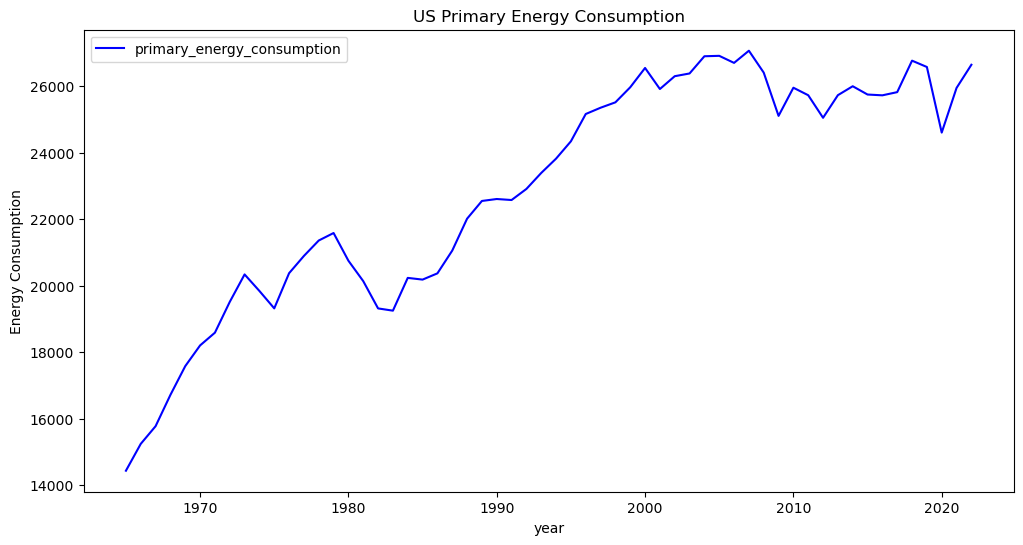

In [20]:
# Visualizing the Pattern
us_energy.plot(figsize=(12, 6), color='blue', title='US Primary Energy Consumption')
plt.ylabel('Energy Consumption')
plt.show()

In [25]:
# Stationarity Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(us_energy['primary_energy_consumption'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
if result[1] <= 0.05:
    print("Result: Data is Stationary (No trend)")
else:
    print("Result: Data is NOT Stationary (It has a trend)")

ADF Statistic: -1.4070720028478212
p-value: 0.5788810546476194
Result: Data is NOT Stationary (It has a trend)


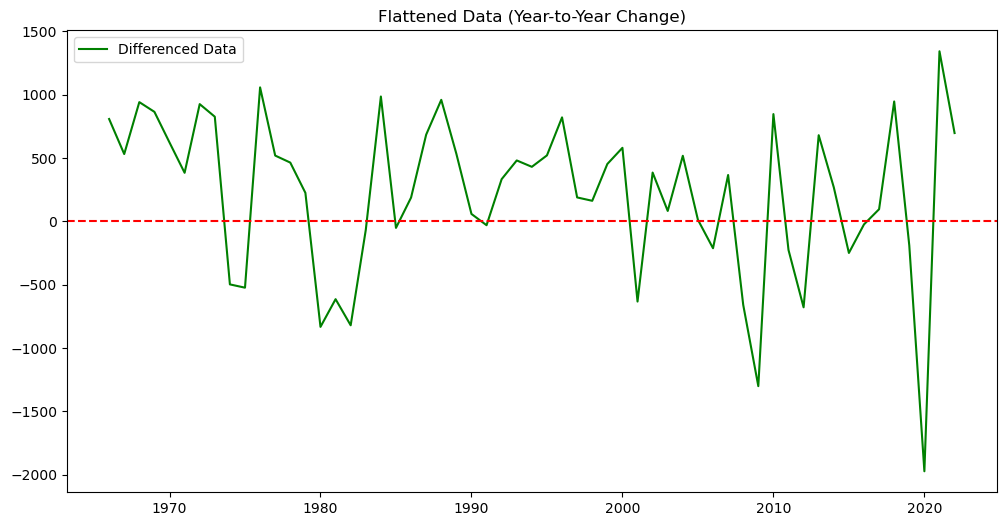

In [28]:
# As data is NOT stationary, need to calculate difference 
us_energy_diff = us_energy.diff().dropna()
plt.figure(figsize=(12, 6))
plt.plot(us_energy_diff, color='green', label='Differenced Data')
plt.title('Flattened Data (Year-to-Year Change)')
plt.axhline(0, color='red', linestyle='--') # Add a line at zero
plt.legend()
plt.show()

In [34]:
from statsmodels.tsa.stattools import adfuller
us_energy['log_consumption'] = np.log(us_energy['primary_energy_consumption'])
us_energy_log_diff = us_energy['log_consumption'].diff().dropna()
result_final = adfuller(us_energy_log_diff)
print(f"New p-value after Log: {result_final[1]}")

if result_final[1] <= 0.05:
    print("SUCCESS! The data is finally stationary.")
else:
    print("Still not there? We will use one more trick.")

New p-value after Log: 1.1144448118464855e-07
SUCCESS! The data is finally stationary.


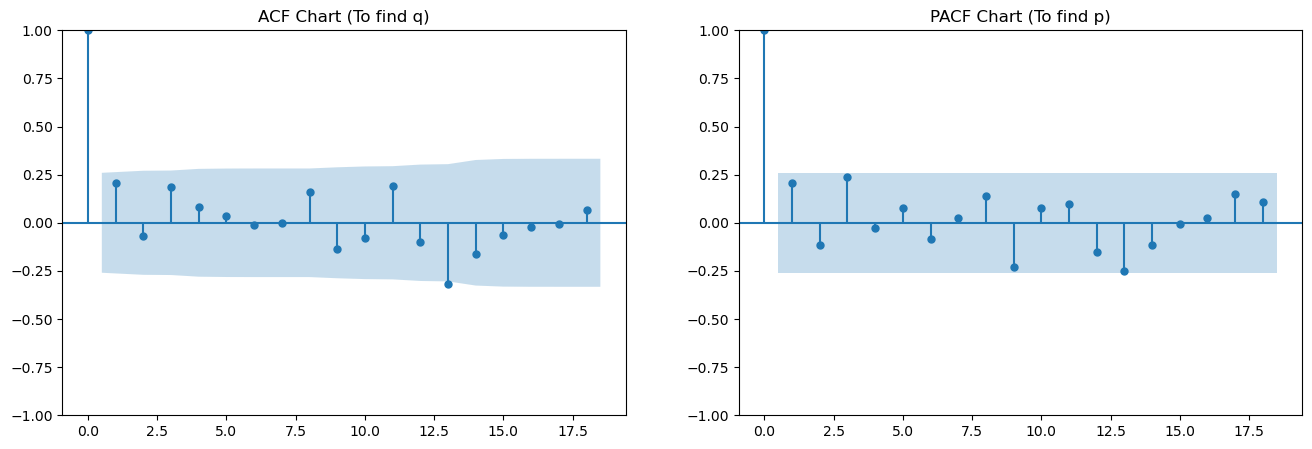

In [36]:
us_energy = df[df['country'] == 'United States'][['year', 'primary_energy_consumption']].copy()
us_energy = us_energy.dropna().set_index('year')
us_energy['log_consumption'] = np.log(us_energy['primary_energy_consumption'])
us_energy_log_diff = us_energy['log_consumption'].diff().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(us_energy_log_diff, ax=ax1)
ax1.set_title('ACF Chart (To find q)')
plot_pacf(us_energy_log_diff, ax=ax2)
ax2.set_title('PACF Chart (To find p)')
plt.show()

In [41]:
from statsmodels.tsa.arima.model import ARIMA
# Define the model using our (p, d, q) numbers
# use 'log_consumption' 
model = ARIMA(us_energy['log_consumption'], order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:        log_consumption   No. Observations:                   58
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 122.033
Date:                Wed, 18 Mar 2026   AIC                           -238.066
Time:                        09:15:53   BIC                           -231.937
Sample:                             0   HQIC                          -235.684
                                 - 58                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3107      0.267     -1.165      0.244      -0.833       0.212
ma.L1          0.6997      0.251      2.787      0.005       0.208       1.192
sigma2         0.0008      0.000      4.743      0.0

In [43]:
# The Multiyear Forecast
forecast_log = model_fit.forecast(steps=10)

#'Log' math to get real energy numbers
forecast_real = np.exp(forecast_log)

#simple timeline for the forecast (Next 10 years)
last_year = us_energy.index.max()
forecast_years = range(last_year + 1, last_year + 11)

#predicted energy for the next decade
print("--- US Energy Consumption Forecast ---")
for year, value in zip(forecast_years, forecast_real):
    print(f"Year {year}: {value:.2f}")

/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


--- US Energy Consumption Forecast ---
Year 2023: 26255.06
Year 2024: 26374.61
Year 2025: 26337.41
Year 2026: 26348.96
Year 2027: 26345.37
Year 2028: 26346.49
Year 2029: 26346.14
Year 2030: 26346.25
Year 2031: 26346.21
Year 2032: 26346.22


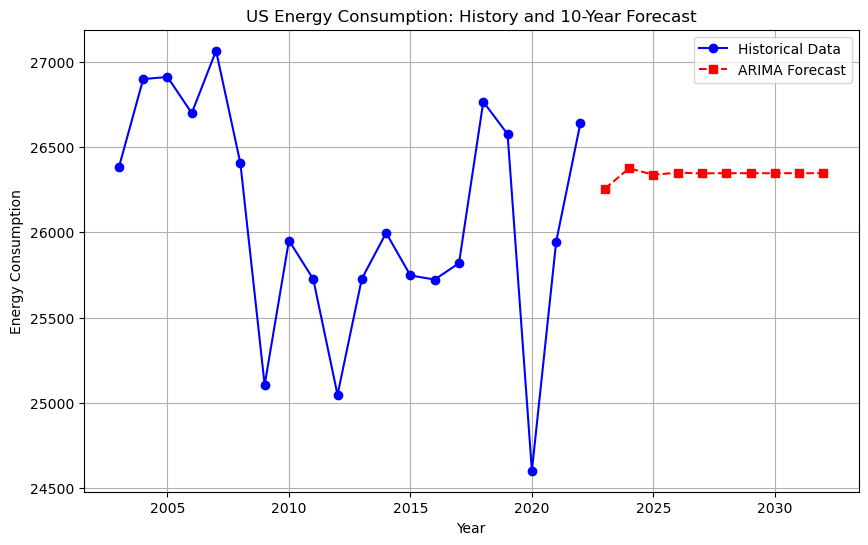

In [45]:
plt.figure(figsize=(10, 6))
plt.plot(us_energy.index[-20:], us_energy['primary_energy_consumption'][-20:], label='Historical Data', color='blue', marker='o')
plt.plot(forecast_years, forecast_real, label='ARIMA Forecast', color='red', linestyle='--', marker='s')
plt.title('US Energy Consumption: History and 10-Year Forecast')
plt.xlabel('Year')
plt.ylabel('Energy Consumption')
plt.legend()
plt.grid(True)
plt.show()